# SPY Log Returns — Benchmark Time Series Models
**Purpose:** Establish simple statistical benchmarks (mean, RW, AR, ARMA) against which the future Markov model will be evaluated.  
**Target variable:** Daily log returns $r_t = \ln(P_t / P_{t-1})$

---
### Benchmark Hierarchy (simplest → richest)

| Model | Equation | Rationale |
|---|---|---|
| **M0** — Historical Mean | $\hat{r}_t = \bar{r}$ | Naive baseline, zero dynamics |
| **M1** — Random Walk | $\hat{r}_t = r_{t-1}$ | Classic efficient market benchmark |
| **M2** — AR(p) | $\hat{r}_t = \phi_0 + \sum_{i=1}^p \phi_i r_{t-i}$ | Linear autoregressive, p selected by AIC |
| **M3** — ARMA(p,q) | $\hat{r}_t = \phi_0 + \sum \phi_i r_{t-i} + \sum \theta_j \varepsilon_{t-j}$ | Best linear predictor, p/q by AIC grid |


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.4})
BLUE, RED, GREEN, ORANGE = '#2166ac', '#d6604d', '#4dac26', '#f4a582'

# ── Reproducibility ────────────────────────────────────────────────────────────
np.random.seed(42)

In [14]:
print()

## 1. Load Data & Train/Test Split

In [2]:
df_train = pd.read_csv(
    '../01_data_preprocessing_eda/data/spy_train_2019-01-01_2024-12-31.csv',
    index_col='Date',
    parse_dates=True
)

df_test = pd.read_csv(
    '../01_data_preprocessing_eda/data/spy_test_2025-01-01_2025-12-31.csv',
    index_col='Date',
    parse_dates=True
)

# ── Identify the log return column ────────────────────────────────────────────
# Assumes a single column of log returns; adjust LOG_RET_COL if named differently
LOG_RET_COL = df_train.columns[0]
print(f'Using column: "{LOG_RET_COL}"')

train = df_train[LOG_RET_COL].dropna()
test  = df_test[LOG_RET_COL].dropna()

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f'Train : {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test  : {len(test)}  obs  ({test.index[0].date()}  → {test.index[-1].date()})')
print(f'Train mean : {train.mean():.6f} | std : {train.std():.6f}')
print(f'Test  mean : {test.mean():.6f}  | std : {test.std():.6f}')
display(pd.concat([train.describe().rename('Train'), test.describe().rename('Test')], axis=1))

Using column: "Adj Close"
Train : 1510 obs  (2019-01-02 → 2024-12-31)
Test  : 250  obs  (2025-01-02  → 2025-12-31)
Train mean : 381.295427 | std : 90.673593
Test  mean : 614.198196  | std : 47.447118


,Train,Test
count,1510.000000,250.000000
mean,381.295427,614.198196
std,90.673593,47.447118
min,204.944855,490.853088
25%,299.960960,581.479218
50%,386.641022,615.345520
75%,429.919159,658.778961
max,597.109314,688.499695


## 2. Evaluation Metrics Helper

In [3]:
def evaluate(actual: pd.Series, predicted: pd.Series, model_name: str) -> dict:
    """Compute a full suite of point-forecast evaluation metrics."""
    e   = actual.values - predicted.values        # residuals
    ae  = np.abs(e)
    ape = ae / np.abs(actual.values + 1e-12)      # avoid div-by-zero

    mse   = mean_squared_error(actual, predicted)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(actual, predicted)
    mape  = np.mean(ape) * 100
    # Directional accuracy: did we get the sign right?
    dir_acc = np.mean(np.sign(actual.values) == np.sign(predicted.values)) * 100
    # Theil's U (ratio vs naive RW — U < 1 means beats random walk)
    rw_rmse = np.sqrt(mean_squared_error(actual.values[1:], actual.values[:-1]))
    theil_u = rmse / (rw_rmse + 1e-12)

    return {
        'Model'       : model_name,
        'RMSE'        : rmse,
        'MAE'         : mae,
        'MAPE (%)'    : mape,
        'Dir. Acc (%)': dir_acc,
        "Theil's U"   : theil_u,
    }

results = []   # collect all model results here

## 3. M0 — Historical Mean (Naive Baseline)

In [4]:
mean_forecast = pd.Series(
    np.full(len(test), train.mean()),
    index=test.index
)

m0 = evaluate(test, mean_forecast, 'M0 — Historical Mean')
results.append(m0)
print(m0)

{'Model': 'M0 — Historical Mean', 'RMSE': np.float64(237.66767484350913), 'MAE': 232.90276848516405, 'MAPE (%)': np.float64(37.539033846026356), 'Dir. Acc (%)': np.float64(100.0), "Theil's U": np.float64(34.88247971011522)}


## 4. M1 — Random Walk (Drift)

In [5]:
# RW: forecast for day t = last observed return (r_{t-1})
# Critical: the first test forecast uses the LAST value of train (boundary bridge)
last_train_val = train.iloc[-1]

rw_vals = np.concatenate([[last_train_val], test.values[:-1]])
rw_forecast = pd.Series(rw_vals, index=test.index)

m1 = evaluate(test, rw_forecast, 'M1 — Random Walk')
results.append(m1)
print(m1)

{'Model': 'M1 — Random Walk', 'RMSE': np.float64(6.800334607013082), 'MAE': 4.41716943359375, 'MAPE (%)': np.float64(0.7454240936424898), 'Dir. Acc (%)': np.float64(100.0), "Theil's U": np.float64(0.9980849693056464)}


## 5. M2 — AR(p): AIC-Based Order Selection

In [6]:
# ── Grid search over AR orders 0–10 ───────────────────────────────────────────
ar_aic = {}
for p in range(0, 11):
    try:
        m = ARIMA(train, order=(p, 0, 0)).fit()
        ar_aic[p] = m.aic
    except Exception:
        pass

best_p = min(ar_aic, key=ar_aic.get)
print(f'AR AIC by order: {ar_aic}')
print(f'Best AR order   : p = {best_p}  (AIC = {ar_aic[best_p]:.2f})')

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency in

AR AIC by order: {0: np.float64(17900.137877624373), 1: np.float64(8660.00876854279), 2: np.float64(8656.171506386036), 3: np.float64(8656.126640410546), 4: np.float64(8657.717409787638), 5: np.float64(8657.727692825105), 6: np.float64(8659.394543411749), 7: np.float64(8653.50521505535), 8: np.float64(8641.074526254393), 9: np.float64(8637.757024117696), 10: np.float64(8622.57675288861)}
Best AR order   : p = 10  (AIC = 8622.58)


In [7]:
# ── Rolling one-step-ahead forecast (walk-forward, no look-ahead) ─────────────
ar_preds = []
history  = train.tolist()

for t in range(len(test)):
    model = ARIMA(history, order=(best_p, 0, 0)).fit()
    yhat  = model.forecast(steps=1)[0]
    ar_preds.append(yhat)
    history.append(test.iloc[t])   # expand window

ar_forecast = pd.Series(ar_preds, index=test.index)

m2 = evaluate(test, ar_forecast, f'M2 — AR({best_p})')
results.append(m2)
print(m2)

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quan

{'Model': 'M2 — AR(10)', 'RMSE': np.float64(6.943751803823747), 'MAE': 4.615357245747342, 'MAPE (%)': np.float64(0.7806755868816205), 'Dir. Acc (%)': np.float64(100.0), "Theil's U": np.float64(1.0191343083086204)}


/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 6. M3 — ARMA(p,q): AIC Grid Search

In [8]:
# ── AIC grid over p ∈ [0,5], q ∈ [0,5] ───────────────────────────────────────
arma_aic = {}
for p, q in product(range(0, 6), range(0, 6)):
    if p == 0 and q == 0:
        continue
    try:
        m = ARIMA(train, order=(p, 0, q)).fit()
        arma_aic[(p, q)] = m.aic
    except Exception:
        pass

best_pq   = min(arma_aic, key=arma_aic.get)
best_p_arma, best_q_arma = best_pq
print(f'Best ARMA order : p={best_p_arma}, q={best_q_arma}  '
      f'(AIC = {arma_aic[best_pq]:.2f})')

# Top 5 models
top5 = sorted(arma_aic.items(), key=lambda x: x[1])[:5]
print('\nTop 5 ARMA models by AIC:')
for (p, q), aic in top5:
    print(f'  ARMA({p},{q}) → AIC = {aic:.2f}')

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency in

Best ARMA order : p=3, q=2  (AIC = 8618.35)

Top 5 ARMA models by AIC:
  ARMA(3,2) → AIC = 8618.35
  ARMA(5,5) → AIC = 8618.78
  ARMA(3,3) → AIC = 8619.00
  ARMA(3,4) → AIC = 8619.38
  ARMA(3,5) → AIC = 8620.77


In [9]:
# ── Rolling one-step-ahead forecast ───────────────────────────────────────────
arma_preds = []
history    = train.tolist()

for t in range(len(test)):
    model = ARIMA(history, order=(best_p_arma, 0, best_q_arma)).fit()
    yhat  = model.forecast(steps=1)[0]
    arma_preds.append(yhat)
    history.append(test.iloc[t])

arma_forecast = pd.Series(arma_preds, index=test.index)

m3 = evaluate(test, arma_forecast, f'M3 — ARMA({best_p_arma},{best_q_arma})')
results.append(m3)
print(m3)

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/quan

{'Model': 'M3 — ARMA(3,2)', 'RMSE': np.float64(12.61013102920076), 'MAE': 5.14497496222863, 'MAPE (%)': np.float64(0.8750969011122017), 'Dir. Acc (%)': np.float64(100.0), "Theil's U": np.float64(1.8507886697575568)}


## 7. Residual Diagnostics (Best Model)

In [10]:
# ── Fit final ARMA on full train set and inspect residuals ─────────────────────
final_model = ARIMA(train, order=(best_p_arma, 0, best_q_arma)).fit()
residuals   = pd.Series(final_model.resid, index=train.index)

print(final_model.summary())

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 1510
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -4302.175
Date:                Tue, 07 Apr 2026   AIC                           8618.350
Time:                        09:48:24   BIC                           8655.589
Sample:                             0   HQIC                          8632.218
                               - 1510                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        381.2977    135.738      2.809      0.005     115.257     647.339
ar.L1         -0.7743      0.032    -24.062      0.000      -0.837      -0.711
ar.L2          0.8865      0.009     96.998      0.0

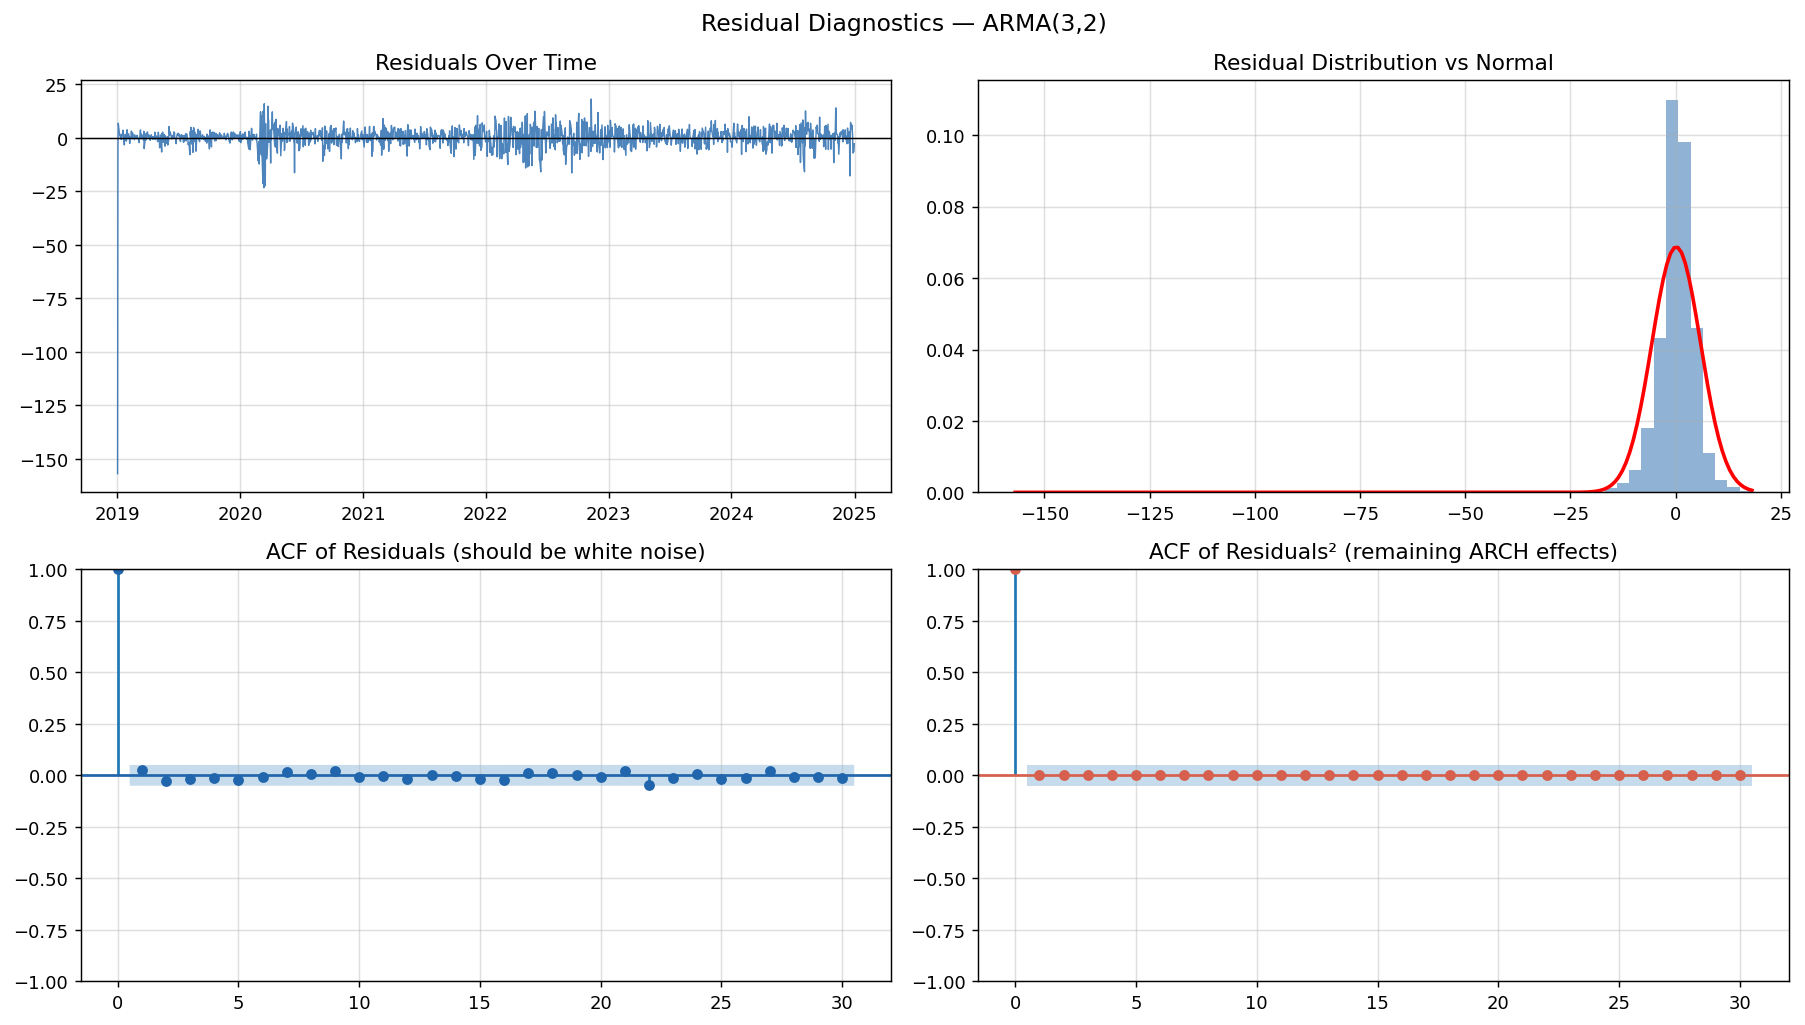


Ljung-Box on residuals:


,lb_stat,lb_pvalue
10,4.771612,0.905903
20,6.953573,0.996835



ARCH-LM (lag=10): stat=289.8332, p=0.000000 → ARCH remaining: True


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0, 0].plot(residuals, color=BLUE, lw=0.8, alpha=0.8)
axes[0, 0].axhline(0, color='black', lw=0.8)
axes[0, 0].set_title('Residuals Over Time')

# Residual histogram vs Normal
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].hist(residuals, bins=60, density=True, color=BLUE, alpha=0.5)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0, 1].set_title('Residual Distribution vs Normal')

# ACF of residuals — should be white noise
plot_acf(residuals, lags=30, ax=axes[1, 0], color=BLUE)
axes[1, 0].set_title('ACF of Residuals (should be white noise)')

# ACF of squared residuals — ARCH effects remaining
plot_acf(residuals**2, lags=30, ax=axes[1, 1], color=RED)
axes[1, 1].set_title('ACF of Residuals² (remaining ARCH effects)')

fig.suptitle(f'Residual Diagnostics — ARMA({best_p_arma},{best_q_arma})', fontsize=13)
fig.tight_layout()
plt.savefig('fig_benchmark_residuals.png', bbox_inches='tight')
plt.show()

# Formal tests
lb   = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
arch = het_arch(residuals, nlags=10)
print('\nLjung-Box on residuals:')
display(lb)
print(f'\nARCH-LM (lag=10): stat={arch[0]:.4f}, p={arch[1]:.6f} → ARCH remaining: {arch[1]<0.05}')

## 8. Forecast vs Actual Plot

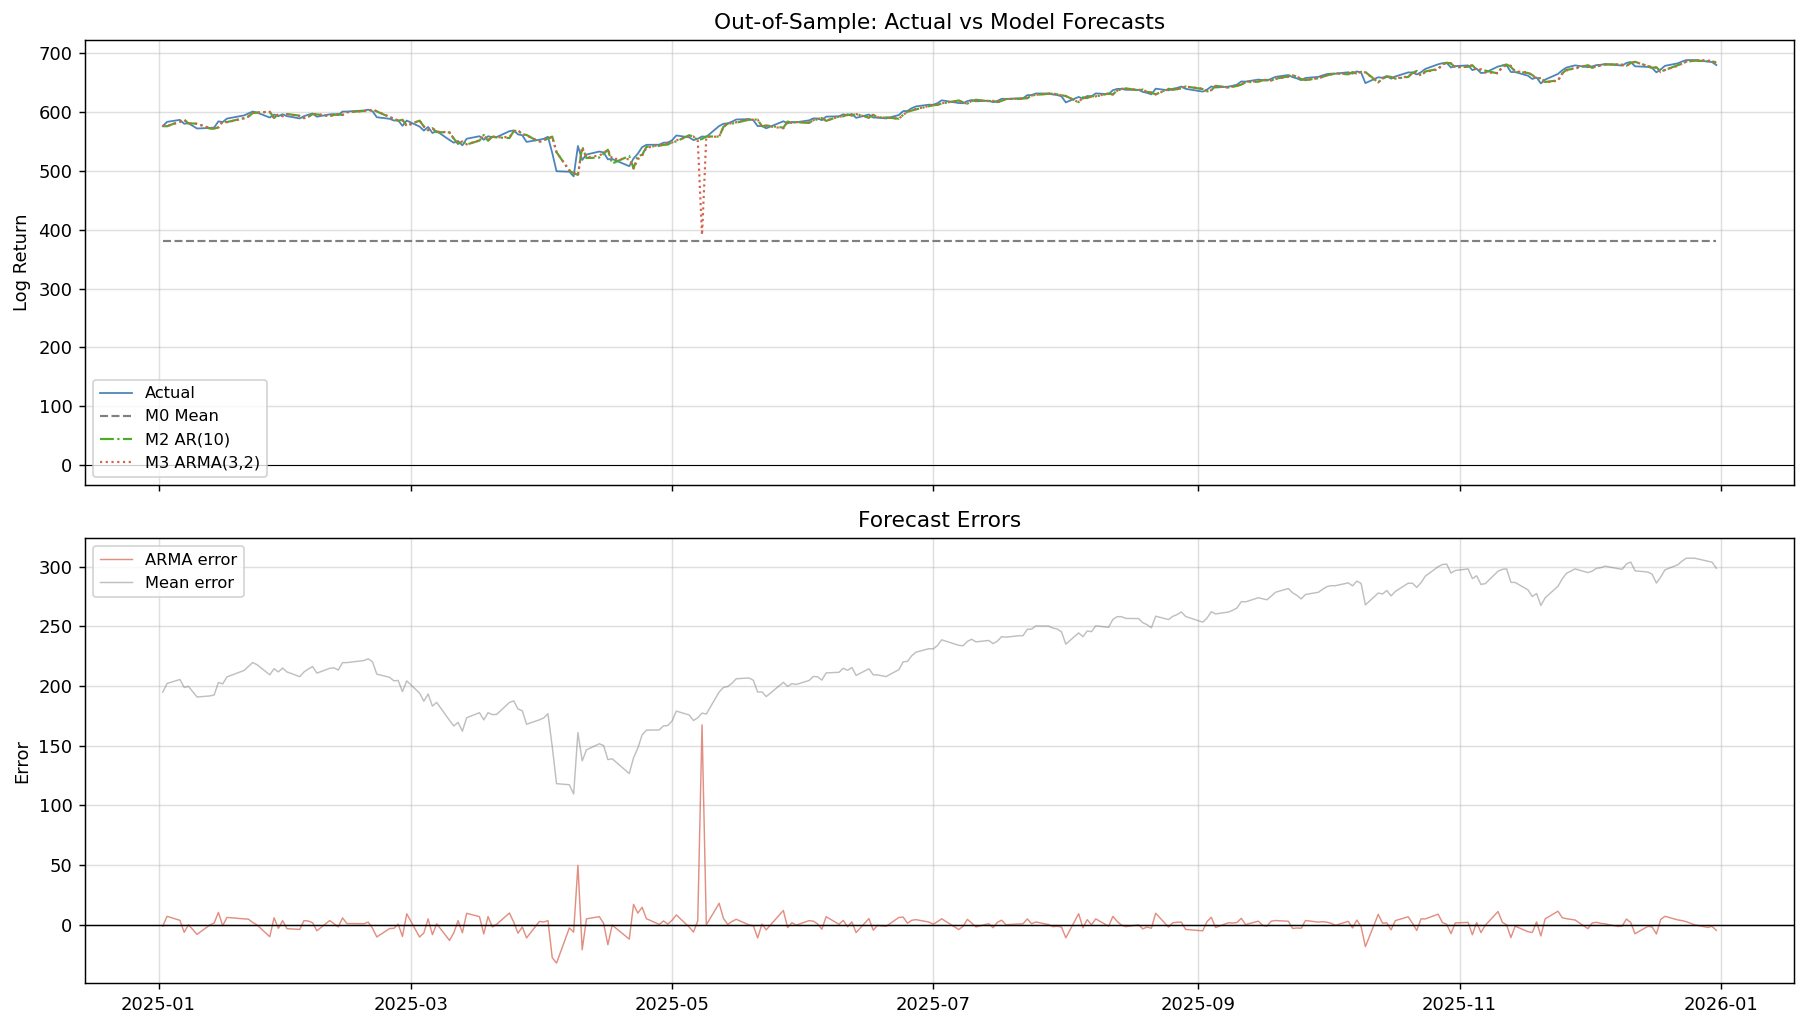

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(test.index, test,           color=BLUE,   lw=1,   label='Actual', alpha=0.8)
axes[0].plot(test.index, mean_forecast,  color='grey', lw=1.2, ls='--', label='M0 Mean')
axes[0].plot(test.index, ar_forecast,    color=GREEN,  lw=1.2, ls='-.',  label=f'M2 AR({best_p})')
axes[0].plot(test.index, arma_forecast,  color=RED,    lw=1.2, ls=':',   label=f'M3 ARMA({best_p_arma},{best_q_arma})')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_title('Out-of-Sample: Actual vs Model Forecasts')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Log Return')

# Forecast errors
axes[1].plot(test.index, test - arma_forecast, color=RED, lw=0.8, alpha=0.7, label='ARMA error')
axes[1].plot(test.index, test - mean_forecast, color='grey', lw=0.8, alpha=0.5, label='Mean error')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Forecast Errors')
axes[1].legend(fontsize=9)
axes[1].set_ylabel('Error')

fig.tight_layout()
plt.savefig('fig_benchmark_forecast.png', bbox_inches='tight')
plt.show()

## 9. Model Comparison Table

In [13]:
results_df = pd.DataFrame(results).set_index('Model')

display(
    results_df.style
    .format({
        'RMSE'        : '{:.6f}',
        'MAE'         : '{:.6f}',
        'MAPE (%)'    : '{:.2f}',
        'Dir. Acc (%)': '{:.2f}',
        "Theil's U"   : '{:.4f}',
    })
    .highlight_min(subset=['RMSE', 'MAE', "Theil's U"], color='lightgreen')
    .highlight_max(subset=['Dir. Acc (%)'], color='lightgreen')
)

print("""
Metric guide:
  RMSE / MAE     : lower is better — penalise forecast errors
  MAPE           : lower is better — scale-free error
  Dir. Acc       : higher is better — % of correct sign predictions
  Theil's U < 1  : model beats naive random walk
  Theil's U = 1  : equivalent to random walk
  Theil's U > 1  : worse than random walk
""")

,RMSE,MAE,MAPE (%),Dir. Acc (%),Theil's U
Model,,,,,
M0 — Historical Mean,237.667675,232.902768,37.54,100.00,34.8825
M1 — Random Walk,6.800335,4.417169,0.75,100.00,0.9981
M2 — AR(10),6.943752,4.615357,0.78,100.00,1.0191
"M3 — ARMA(3,2)",12.610131,5.144975,0.88,100.00,1.8508



Metric guide:
  RMSE / MAE     : lower is better — penalise forecast errors
  MAPE           : lower is better — scale-free error
  Dir. Acc       : higher is better — % of correct sign predictions
  Theil's U < 1  : model beats naive random walk
  Theil's U = 1  : equivalent to random walk
  Theil's U > 1  : worse than random walk

